In [1]:
'''
Key Features of the Dataset¶

url_length: The length of the URL.

n_slash: The count of ‘/’ characters in the URL.

n_questionmark: The count of ‘?’ characters in the URL.

n_equal: The count of ‘=’ characters in the URL.

n_at: The count of ‘@’ characters in the URL.

n_and: The count of ‘&’ characters in the URL.

n_exclamation: The count of ‘!’ characters in the URL.

n_asterisk: The count of ‘*’ characters in the URL.

n_hashtag: The count of ‘#’ characters in the URL.

n_percent: The count of ‘%’ characters in the URL.

dots_per_length: The amount of '.' per URL query.

hyphens_per_length: The amount of '-' per URL query.

is_long_url: Is the URL query an abnormally long string.

has_many_dots: Does it have abnomormal amounts of '.'

has_ssl: Does it have an SSL certificate.

is_cloudflare_protected: Is the URL Cloudflare protected.

special_char_density: Ratio of special characters (*&@#) within URL.

suspicious_tld_risk: Risk of URL containing suspicious extensions, domains, and patterns.

has_redirects: Does URL have redirects.

risk_score: Ultimate risk score of URL based on characteristics.

url_complexity: Ultimate URL complexity based on characteristics.

phishing: The Labels of the URL. 1 is phishing and 0 is legitimate.
'''

"\nKey Features of the Dataset¶\n\nurl_length: The length of the URL.\n\nn_slash: The count of ‘/’ characters in the URL.\n\nn_questionmark: The count of ‘?’ characters in the URL.\n\nn_equal: The count of ‘=’ characters in the URL.\n\nn_at: The count of ‘@’ characters in the URL.\n\nn_and: The count of ‘&’ characters in the URL.\n\nn_exclamation: The count of ‘!’ characters in the URL.\n\nn_asterisk: The count of ‘*’ characters in the URL.\n\nn_hashtag: The count of ‘#’ characters in the URL.\n\nn_percent: The count of ‘%’ characters in the URL.\n\ndots_per_length: The amount of '.' per URL query.\n\nhyphens_per_length: The amount of '-' per URL query.\n\nis_long_url: Is the URL query an abnormally long string.\n\nhas_many_dots: Does it have abnomormal amounts of '.'\n\nhas_ssl: Does it have an SSL certificate.\n\nis_cloudflare_protected: Is the URL Cloudflare protected.\n\nspecial_char_density: Ratio of special characters (*&@#) within URL.\n\nsuspicious_tld_risk: Risk of URL contain

In [2]:
# necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.metrics import classification_report, f1_score, confusion_matrix, precision_recall_curve, average_precision_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import joblib
import warnings


In [3]:
# Import and Read Data

data_df = pd.read_csv('web-page-phishing.csv')

print("Number of rows within data: ", data_df.shape[0])
print("Number of columns within data: ", data_df.shape[1])
display(data_df.head())



Number of rows within data:  100077
Number of columns within data:  20


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [4]:
# Data Cleaning and Preprocessing

In [5]:
# Create a copy of data and then shuffle
data_copy = data_df.copy()
data_copy = data_copy.sample(frac=1, random_state=42).reset_index(drop=True)
data_copy.head()

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,30,2,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,35,2,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,148,2,0,0,2,0,2,0,2,0,0,0,0,0,0,0,0,0,0,1
3,49,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,31,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Convert no. of characters (dots, hyphens, etc.) into a ratio with respect to its url length
# The ratio gets put into a new column
data_copy['dots_per_length'] = data_copy['n_dots'] / (data_copy['url_length'] + 1)
data_copy['hyphens_per_length'] = data_copy['n_hypens'] / (data_copy['url_length'] + 1)
data_copy['is_long_url'] = (data_copy['url_length'] > 75).astype(int)
data_copy['has_many_dots'] = (data_copy['n_dots'] > 4).astype(int)
data_copy['has_redirects'] = (data_copy['n_redirection'] > 0).astype(int)


In [7]:
# The data does not indicate whether a url has ssl certificates or cloudflare protection
# Having any one of these gives urls credibility
# for further/future training, these values will still be included in the data as per conditions:
#   has_ssl will have a value of 1 for 70% of non-phishing rows and 30% of phishing data
#   is_cloudflare_protected will have a value of 1 for 40% of non phishing data and 5% phishing data

# Add has_ssl column (1 for all legitimate URLs, random for phishing)
data_copy['has_ssl'] = 1
phishing_mask = data_copy['phishing'] == 1
data_copy.loc[phishing_mask, 'has_ssl'] = np.random.choice(
    [0, 1],
    size=sum(phishing_mask),
    p=[0.7, 0.3]
)

# Add cloudflare protection (randomized with specific distribution)
data_copy['is_cloudflare_protected'] = 0
legitimate_mask = data_copy['phishing'] == 0
data_copy.loc[legitimate_mask, 'is_cloudflare_protected'] = np.random.choice(
    [0, 1],
    size=sum(legitimate_mask),
    p=[0.6, 0.4]
)
data_copy.loc[phishing_mask, 'is_cloudflare_protected'] = np.random.choice(
    [0, 1],
    size=sum(phishing_mask),
    p=[0.95, 0.05]
)

In [8]:
# Special character density (higher in phishing URLs)
data_copy['special_char_density'] = (
    data_copy['n_hypens'] + data_copy['n_underline'] +
    data_copy['n_at'] + data_copy['n_equal'] + data_copy['n_dollar'] +
    data_copy['n_percent'] + data_copy['n_hastag']
) / (data_copy['url_length'] + 1)

# Suspicious TLD approximation (can't directly check TLD without URL string)
data_copy['suspicious_tld_risk'] = 0
 # 70% medium/high risk for phishing
data_copy.loc[phishing_mask, 'suspicious_tld_risk'] = np.random.choice(
    [0, 1, 2],
    size=sum(phishing_mask),
    p=[0.3, 0.4, 0.3]
)
 # 80% low risk for legitimate
data_copy.loc[legitimate_mask, 'suspicious_tld_risk'] = np.random.choice(
    [0, 1, 2],
    size=sum(legitimate_mask),
    p=[0.8, 0.15, 0.05]
)

In [9]:
# Combined risk score based on multiple factors
data_copy['risk_score'] = (
    data_copy['is_long_url'] * 2 +
    data_copy['has_many_dots'] * 1.5 +
    data_copy['special_char_density'] * 10 +
    data_copy['has_redirects'] * 3 -
    data_copy['has_ssl'] * 2 -
    data_copy['is_cloudflare_protected'] * 2
)

# Suspicious URL complexity (higher in phishing URLs)
data_copy['url_complexity'] = (
    data_copy['url_length'] * 0.01 +
    data_copy['n_dots'] * 0.5 +
    data_copy['n_hypens'] * 0.3 +
    data_copy['n_questionmark'] * 0.7 +
    data_copy['n_equal'] * 0.7 +
    data_copy['n_at'] * 2
)

In [10]:
# Format
data_copy.drop(['n_dots', 'n_hypens', 'n_redirection', 'n_underline', 'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_dollar'], axis=1, inplace=True)
data_copy = data_copy[['url_length', 'n_slash', 'n_questionmark', 'n_equal', 'n_at', 'n_and',
       'n_exclamation', 'n_asterisk', 'n_hastag', 'n_percent',
       'dots_per_length', 'hyphens_per_length', 'is_long_url', 'has_many_dots',
       'has_ssl', 'is_cloudflare_protected', 'special_char_density', 'suspicious_tld_risk', 'has_redirects',
       'risk_score', 'url_complexity','phishing']]
data_copy.head()

# Save data
data_copy.to_csv('final_data.csv', index=False)

In [11]:
data_copy.isnull().sum()


url_length                 0
n_slash                    0
n_questionmark             0
n_equal                    0
n_at                       0
n_and                      0
n_exclamation              0
n_asterisk                 0
n_hastag                   0
n_percent                  0
dots_per_length            0
hyphens_per_length         0
is_long_url                0
has_many_dots              0
has_ssl                    0
is_cloudflare_protected    0
special_char_density       0
suspicious_tld_risk        0
has_redirects              0
risk_score                 0
url_complexity             0
phishing                   0
dtype: int64

In [12]:
data_copy.duplicated().any()


np.True_

In [13]:
# Frequency count
cols = data_copy.columns
for col in cols:
    print(f"\n{data_copy[col].unique()}")
    print(f"{data_copy[col].value_counts()}")



[  30   35  148   49   31   14   18   41   44   24   25   17   22   32
   19   11   20   12   76   33   77   13   53   23   50    6   27   15
   16    9   37   47   10   91   65   84   66   21    7   26   59   46
   70   52   63   62   89   29   39   54   61  132   86   40    8  102
   78   43  153   57   48   34  118   64   36   71   45   72   58  373
   42  115   28   55  135  109  110  195   83  122   51  316   56   73
  127  114  383   92  162  242  250   88   99   69   75  241   60  157
   68  100   74  229  156  103  172   95  161  141   38  106  294  116
   67   85  180   82   90  105   97   81  107  557  113  131  124  144
  230  147  136  142  119   79  289  126  145  187  133  169  117  270
  265  130  128   93  366  125  238  123   80  203  206  214  138  104
  164  140  328  268  199  377  280  418  101  190  478  297  257  300
  243  121  143  202  129   96  182  155  279   87  271  159  285  111
  166  120  151   98  200  216  204  210  259  234  232  207  176  275
  108

In [14]:
data_copy.describe().round(2)


,url_length,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_asterisk,n_hastag,n_percent,...,is_long_url,has_many_dots,has_ssl,is_cloudflare_protected,special_char_density,suspicious_tld_risk,has_redirects,risk_score,url_complexity,phishing
count,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00,...,100077.0,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00,100077.00
mean,39.18,1.14,0.02,0.22,0.02,0.14,0.00,0.00,0.00,0.11,...,0.1,0.03,0.74,0.27,0.01,0.52,0.34,-0.64,1.84,0.36
std,47.97,1.83,0.17,0.96,0.27,0.91,0.08,0.28,0.06,1.70,...,0.3,0.17,0.44,0.44,0.02,0.73,0.48,2.23,1.85,0.48
min,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,-4.00,0.54,0.00
25%,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,-2.00,1.16,0.00
50%,24.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,1.00,0.00,0.00,0.00,0.00,-1.00,1.26,0.00
75%,44.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,1.00,1.00,0.02,1.00,1.00,1.00,1.83,1.00
max,4165.00,44.00,9.00,23.00,43.00,26.00,10.00,60.00,13.00,174.00,...,1.0,1.00,1.00,1.00,0.36,2.00,1.00,7.76,91.68,1.00


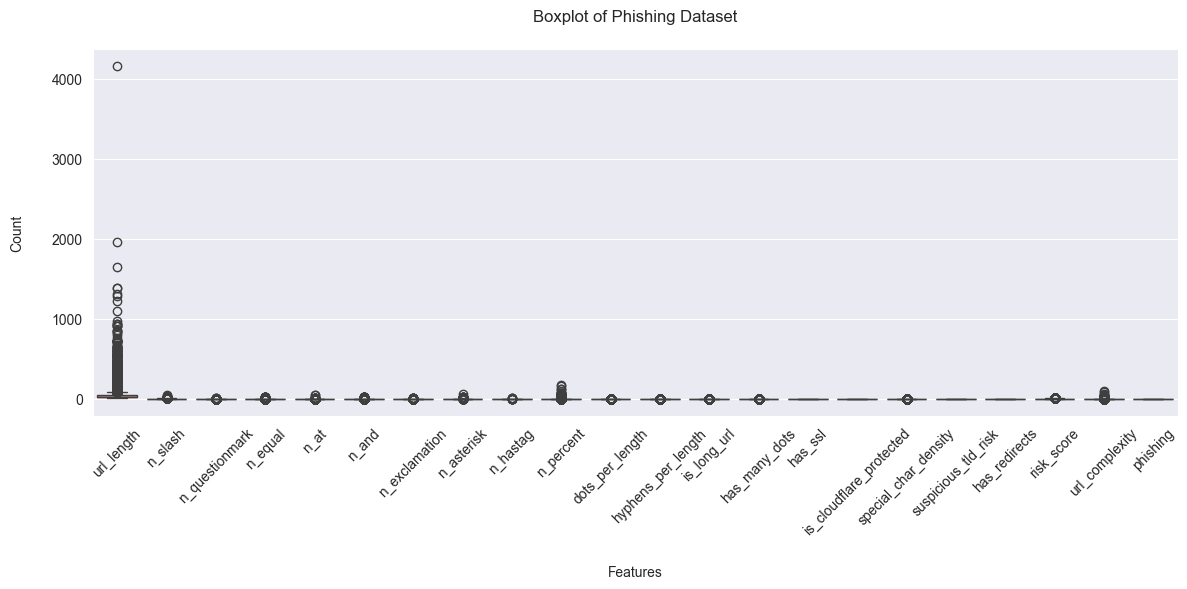

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data_copy)
plt.title('Boxplot of Phishing Dataset', pad=20)
plt.ylabel('Count', labelpad=20)
plt.xlabel('Features', labelpad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Number of non-phishing values:  63715
Number of phishing values:  36362


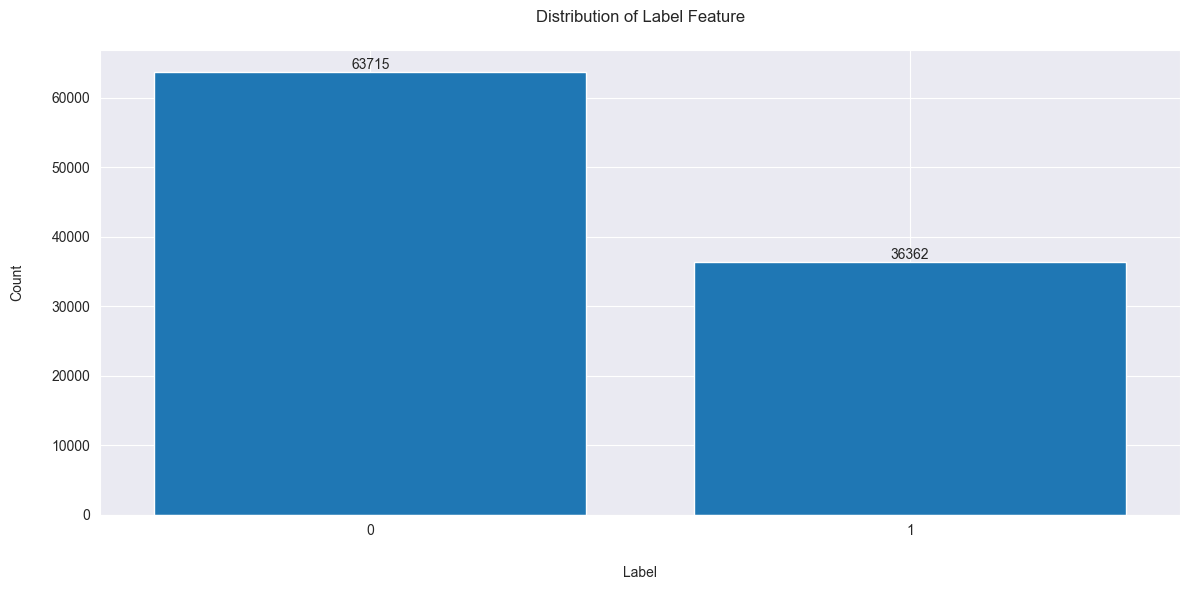

In [16]:
# Data distribution
print("Number of non-phishing values: ", len(data_copy[data_copy['phishing'] == 0]))
print("Number of phishing values: ", len(data_copy[data_copy['phishing'] == 1]))

# Distribution of Feature
counts = data_copy['phishing'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
bplot = plt.bar(counts.index, counts.values, align='center')
plt.title('Distribution of Label Feature', pad=20)
plt.ylabel('Count', labelpad=20)
plt.xlabel('Label', labelpad=20)
plt.xticks([0, 1], ['0', '1'])
plt.xlim(-0.5, 1.5)
plt.bar_label(bplot)
plt.tight_layout()
plt.show()

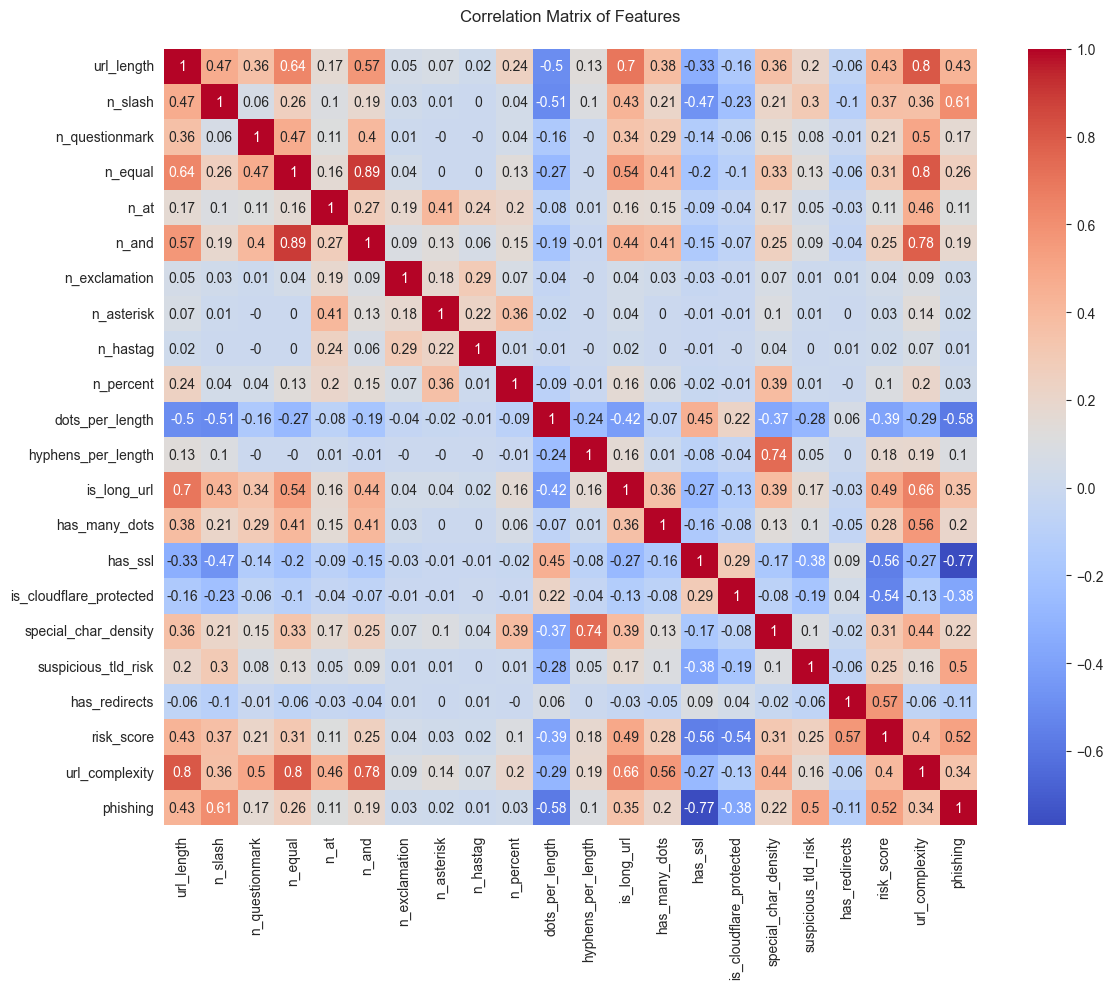

In [17]:
# Correlation Matrix
corr = data_copy.corr().round(2)
ndf = corr.loc[corr.max(axis=1) > 0.90, corr.max(axis=0) > 0.90]
plt.figure(figsize=(12, 10))
sns.heatmap(ndf, cmap='coolwarm', annot=True)
plt.title("Correlation Matrix of Features", pad=20)
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

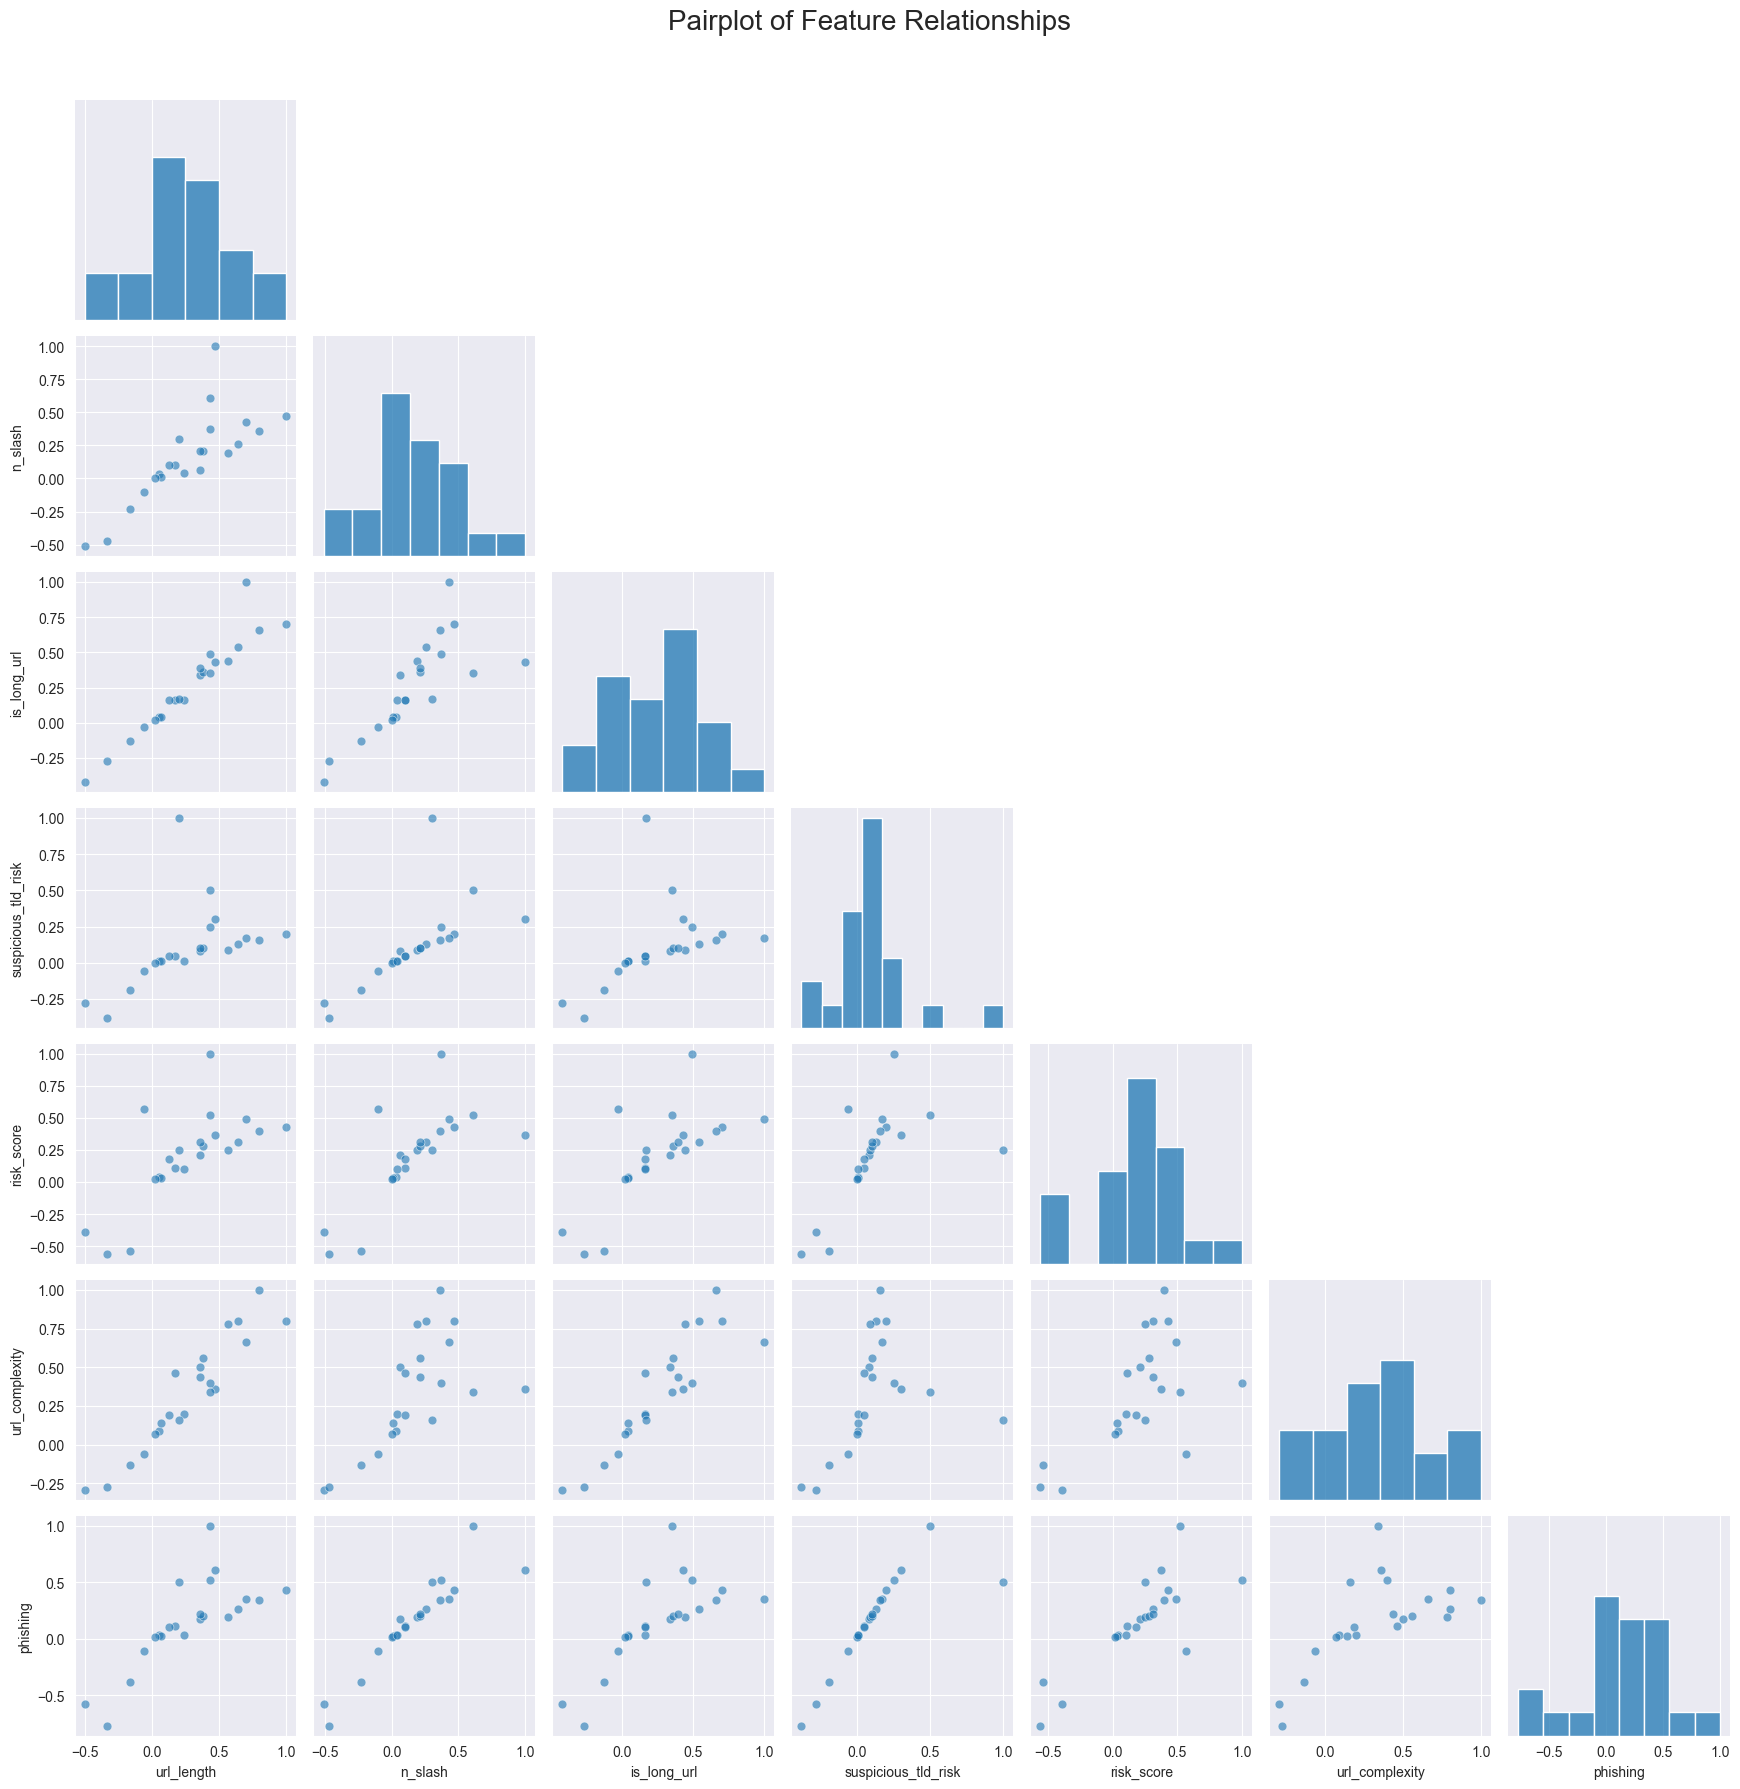

In [18]:
# Pairplot of relationships
plt.figure(figsize=(12,6))
sns.pairplot(
    corr[['url_length', 'n_slash', 'is_long_url', 'suspicious_tld_risk', 'risk_score', 'url_complexity', 'phishing']],
    corner=True,
    plot_kws={'alpha': 0.6, 's': 40},
    diag_kws={'fill': True}
)
plt.suptitle("Pairplot of Feature Relationships", y=1.02, fontsize=20)
plt.tight_layout()
plt.show()


In [19]:
# Focus on High Correlations
corr_matrix = data_copy.corr()
phishing_corr = corr_matrix['phishing'].sort_values(ascending=False)
print("Correlation of Features to Phishing:")
print(phishing_corr.head(10))


Correlation of Features to Phishing:
phishing                1.000000
n_slash                 0.611472
risk_score              0.523235
suspicious_tld_risk     0.496113
url_length              0.430125
is_long_url             0.349660
url_complexity          0.340643
n_equal                 0.260462
special_char_density    0.215315
has_many_dots           0.203592
Name: phishing, dtype: float64


In [20]:
# Set features
X = data_copy.drop('phishing', axis=1)
y = data_copy['phishing']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)


In [21]:
# Scale data
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)
joblib.dump(scaler, '../scaler.pkl')


['../scaler.pkl']

In [22]:
# Params
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 0.5],
    'n_estimators': [100, 200],
}

# Calculate class weights
phishing_weight = len(y_train) / (2 * np.bincount(y_train)[1])
not_phishing_weight = len(y_train) / (2 * np.bincount(y_train)[0])

# Train model
model = RandomForestClassifier(
    class_weight={0: not_phishing_weight, 1: phishing_weight},
    max_depth=10,
    random_state=42
)
grid_search = GridSearchCV(model, param_grid, scoring='precision', cv=3, n_jobs=-1)
grid_search.fit(X_scaled_train, y_train)
best_model = grid_search.best_estimator_


In [23]:
# Predict the labels for the test set
y_pred = best_model.predict(X_scaled_test)

# Calculate f1, accuracy, precision, and recall
f1 = round(f1_score(y_test, y_pred, average='micro'), 2)
print(classification_report(y_test, y_pred, target_names=['Phishing', 'Not Phishing']))
print("F1 Score: ", f1)


              precision    recall  f1-score   support

    Phishing       0.97      0.97      0.97     12720
Not Phishing       0.95      0.95      0.95      7296

    accuracy                           0.96     20016
   macro avg       0.96      0.96      0.96     20016
weighted avg       0.96      0.96      0.96     20016

F1 Score:  0.96


In [24]:
# Cross Validation
cv_scores = cross_val_score(best_model, X_scaled_test, y_test, cv=5, scoring='f1_weighted')
print(f'Average cross-validated F1 score: {cv_scores.mean():.2f}')


Average cross-validated F1 score: 0.95


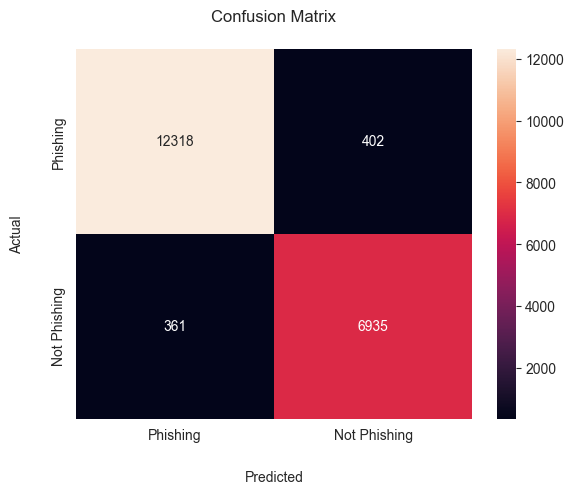

In [25]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Phishing', 'Not Phishing'], yticklabels=['Phishing', 'Not Phishing'])
plt.ylabel('Actual', labelpad=20)
plt.xlabel('Predicted', labelpad=20)
plt.title('Confusion Matrix', pad=20)
plt.show()


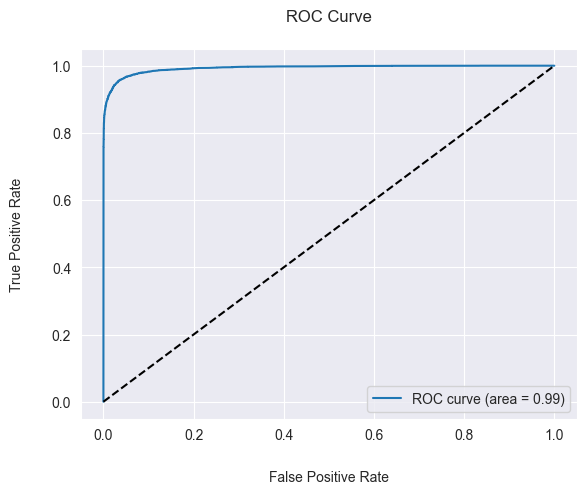

In [26]:
# ROC curve
y_scores = best_model.predict_proba(X_scaled_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_scores)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate', labelpad=20)
plt.ylabel('True Positive Rate', labelpad=20)
plt.title('ROC Curve', pad=20)
plt.legend(loc='lower right')
plt.show()


In [27]:
joblib.dump(best_model, '../phishing_model.pkl')

['../phishing_model.pkl']